In [17]:
# print("hello")

In [18]:
# import idx2numpy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

In [19]:
#Loading the training images and labels

file_name = "mnist.npz"

with np.load(file_name) as data:
    X_train = data['x_train']
    y_train = data['y_train']
    X_test = data['x_test']
    y_test = data['y_test']


print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [20]:
filter=np.isin(y_train,[0,1,2])
test_filter=np.isin(y_test,[0,1,2])



X_train_sampled=X_train[filter]
y_train_final=y_train[filter]


X_test_sampled=X_test[test_filter]
y_test_final=y_test[test_filter]

print(X_train_sampled.shape)
print(X_test_sampled.shape)

(18623, 28, 28)
(3147, 28, 28)


In [21]:
def converrt(x,number):
    my_array = np.zeros((784, number))
    for i in range(number):
        k=0
        for j in range(784):
            dj=j%28
            k=j//28
            my_array[j][i]=x[i][dj][k]/255.0
            
    return my_array



no_train_observations=X_train_sampled.shape[0]
X_train_final=converrt(X_train_sampled,no_train_observations)
no_test_observations=X_test_sampled.shape[0]
X_test_final=converrt(X_test_sampled,no_test_observations)

print(X_train_final.shape)
print(X_test_final.shape)

(784, 18623)
(784, 3147)


## Finding cov and Mean


In [22]:
mean=np.zeros((784,1))

for i in range(784):
    sum=0
    for j in range(no_train_observations):
        sum+=X_train_final[i][j]
    mean[i][0]=sum/no_train_observations    

X_c=X_train_final-mean

sigma=(X_c @ X_c.T)/(no_train_observations-1)

identity=np.eye(784)

print(sigma.shape)



(784, 784)


## Finding eigen val and vectors


In [23]:
eigenvalues,eigenvectors=np.linalg.eigh(sigma)

print(eigenvalues.shape)
print(eigenvectors.shape)

eig=[]

for i in range(784):
    eig.append((eigenvalues[i],eigenvectors[:,i]))


eig.sort(key=lambda x: x[0], reverse=True)


sor_values=np.sort(eigenvalues)[::-1]

tot_sum=np.sum(eigenvalues)
# ret= tot_sum*0.75  # Retaining 75% variance

p=10
# curr_sum=0
# while(p<784 and curr_sum<ret):
#     curr_sum+=sor_values[p]
#     p+=1

print("No. of components : ",p)

U=eig[0][1].reshape(-1, 1)


for i in range(1,p):
    new_col = eig[i][1].reshape(-1, 1)
    U = np.hstack((U, new_col))

print(U.shape)
    

(784,)
(784, 784)
No. of components :  10
(784, 10)


## Obtaining the projected centered matrix


In [24]:
Y = U.T @ X_c

print(Y.shape)

(10, 18623)


## Defining Target Vectors


In [25]:
y_0 = (y_train_final == 0).astype(int) 
y_1 = (y_train_final == 1).astype(int)
y_2 = (y_train_final == 2).astype(int)

Best Ridge lambda: 10  and  Test MSE: 0.0512
Best Lasso lambda: 0.0001  and  Test MSE: 0.0512


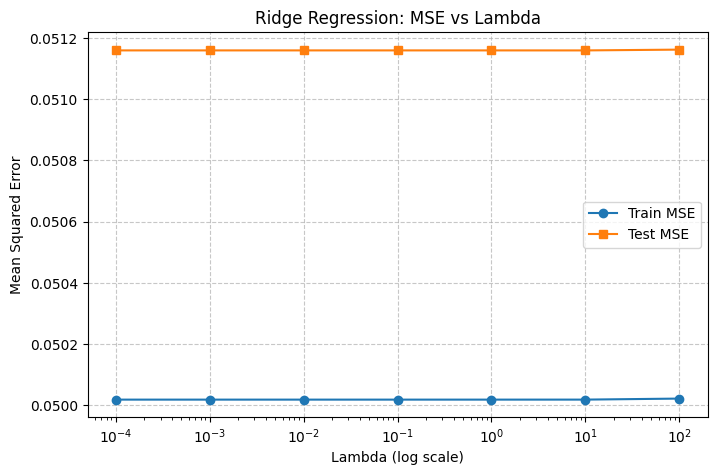

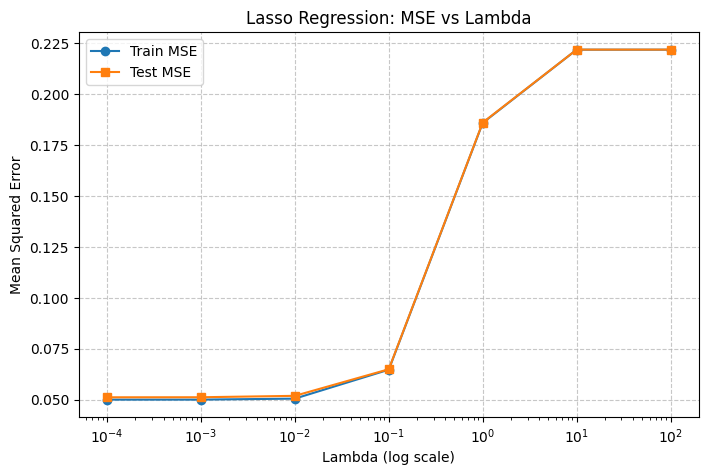

In [ ]:
X_pca=Y.T 

#matrix shape(18623,3)
Y_targets=np.column_stack((y_0,y_1,y_2))


X_tr=X_pca
Y_tr  =Y_targets
X_tr_b=np.column_stack((X_tr,np.ones(X_tr.shape[0])))

#project and prepare test set
X_test_c  =X_test_final - mean
X_test_pca=(U.T @ X_test_c).T    #shape (N_test,10)
X_test_pca_b=np.column_stack((X_test_pca,np.ones(X_test_pca.shape[0])))

Y_test_targets=np.column_stack(((y_test_final == 0).astype(int),(y_test_final == 1).astype(int),(y_test_final == 2).astype(int)))

lambdas=[10**-4,10**-3,10**-2,10**-1,1,10,100]

ridge_train_mse=[]
ridge_test_mse= []
lasso_train_mse= []
lasso_test_mse=[]
ridge_weights_path= []   # Weights for Ridge
lasso_weights_path=[]  # Weights for Lasso
non_zero_lasso= []  # Count of non-zero weights
target_class_idx=1

best_ridge_l= 0
best_lasso_l= 0
ridge_mn=float('inf')
lasso_mn=float('inf')
W_best_ridge=None
lasso_best_model=None

for l in lambdas:
    # Ridge
    I=np.eye(X_tr_b.shape[1])

    W_ridge=np.linalg.inv(X_tr_b.T @ X_tr_b+l*I) @ X_tr_b.T @ Y_tr

    ridge_weights_path.append(W_ridge[:,target_class_idx])

    pred_tr_ridge =X_tr_b@ W_ridge
    pred_test_ridge=X_test_pca_b @ W_ridge

    ridge_train_mse.append(np.mean((pred_tr_ridge - Y_tr)**2))
    r_test_mse=np.mean((pred_test_ridge - Y_test_targets)**2)
    ridge_test_mse.append(r_test_mse)

    if r_test_mse < ridge_mn:
        ridge_mn =r_test_mse
        best_ridge_l=l
        W_best_ridge=W_ridge

    #Lasso
    lasso=Lasso(alpha=l,max_iter=10000)
    lasso.fit(X_tr,Y_tr)

    lasso_weights_path.append(lasso.coef_[target_class_idx])
    non_zero_lasso.append(np.count_nonzero(lasso.coef_))

    pred_tr_lasso  =lasso.predict(X_tr)
    pred_test_lasso=lasso.predict(X_test_pca)

    lasso_train_mse.append(np.mean((pred_tr_lasso - Y_tr)**2))
    l_test_mse=np.mean((pred_test_lasso - Y_test_targets)**2)
    lasso_test_mse.append(l_test_mse)

    if l_test_mse < lasso_mn:
        lasso_mn =l_test_mse
        best_lasso_l =l
        lasso_best_model=lasso

ridge_weights_path=np.array(ridge_weights_path)
lasso_weights_path=np.array(lasso_weights_path)

print(f'Best Ridge lambda: {best_ridge_l}  and  Test MSE: {ridge_mn:.4f}')
print(f'Best Lasso lambda: {best_lasso_l}  and  Test MSE: {lasso_mn:.4f}')

#PLOTS 
plt.figure(figsize=(8,5))
plt.plot(lambdas,ridge_train_mse,label='Train MSE',marker='o')
plt.plot(lambdas,ridge_test_mse, label='Test MSE', marker='s')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression: MSE vs Lambda')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()



plt.figure(figsize=(8,5))
plt.plot(lambdas,lasso_train_mse,label='Train MSE',marker='o')
plt.plot(lambdas,lasso_test_mse, label='Test MSE', marker='s')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression: MSE vs Lambda')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)

plt.show()


In [27]:
lambdas=[1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]

print("Lambda | Ridge Train | Ridge Test | Lasso Train | Lasso Test")
print()
for i, l in enumerate(lambdas):
    r_tr=ridge_train_mse[i]
    r_te=ridge_test_mse[i]
    l_tr=lasso_train_mse[i]
    l_te=lasso_test_mse[i]
    
    print(f"{l}    {r_tr:.8f}    {r_te:.8f}    {l_tr:.8f}    {l_te:.8f}")

Lambda | Ridge Train | Ridge Test | Lasso Train | Lasso Test

0.0001    0.05001913    0.05115919    0.05001918    0.05116124
0.001    0.05001913    0.05115919    0.05002423    0.05118441
0.01    0.05001913    0.05115919    0.05050495    0.05187376
0.1    0.05001913    0.05115919    0.06471021    0.06492937
1    0.05001913    0.05115918    0.18586953    0.18602350
10    0.05001916    0.05115914    0.22181001    0.22183999
100    0.05002251    0.05116173    0.22181001    0.22183999


### Plot of regularization paths


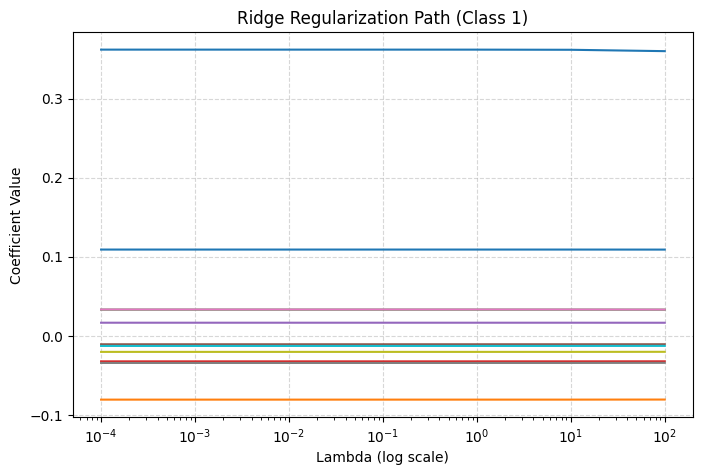

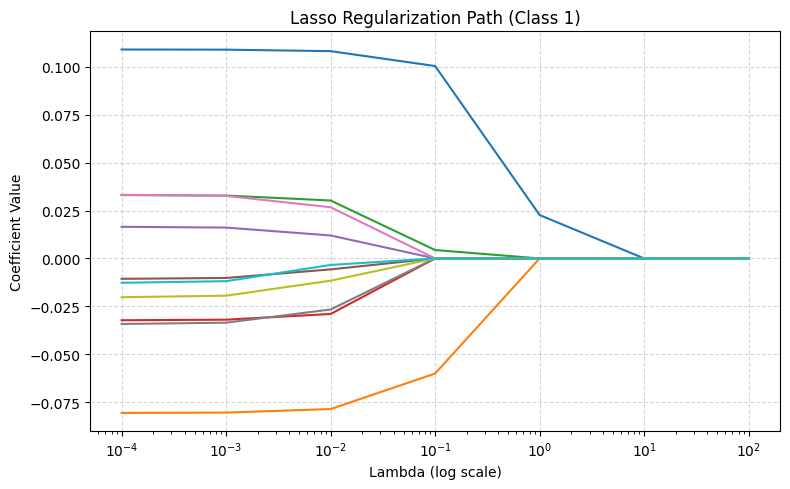

In [28]:


#Ridge Path
plt.figure(figsize=(8, 5))
plt.plot(lambdas, ridge_weights_path)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regularization Path (Class 1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Lasso Path
plt.figure(figsize=(8, 5))
plt.plot(lambdas, lasso_weights_path)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regularization Path (Class 1)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Plot of Lasso non zero coeff


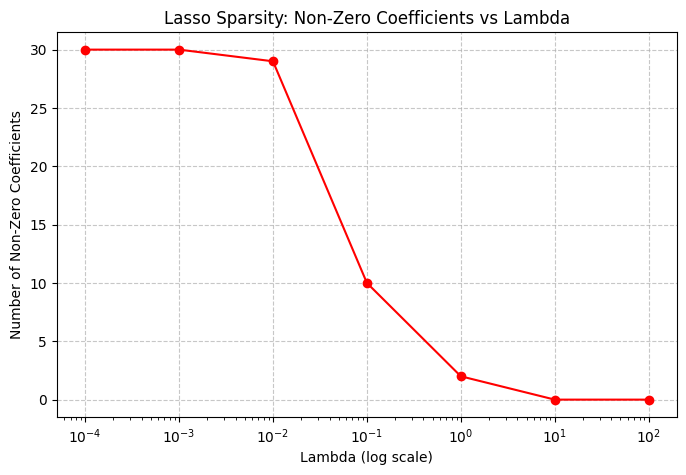

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(lambdas, non_zero_lasso, marker='o', color='red', linestyle='-')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Number of Non-Zero Coefficients')
plt.title('Lasso Sparsity: Non-Zero Coefficients vs Lambda')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### For other pca dimensions


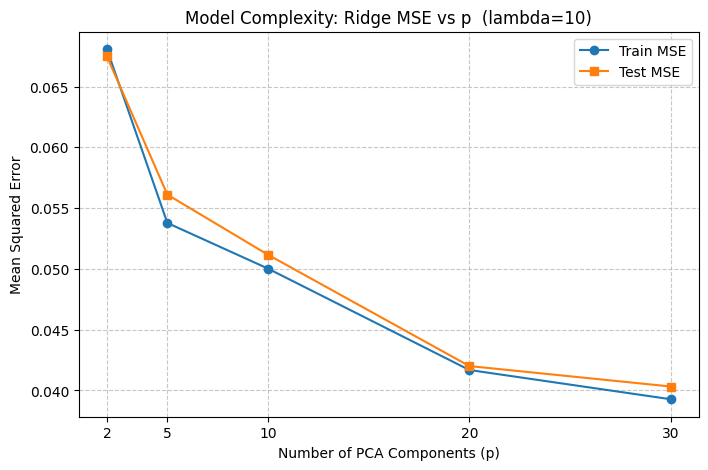

In [ ]:
#Values of p to test
p_values=[2,5,10,20,30]

p_train_mse=[]
p_test_mse =[]

l_opt=best_ridge_l

for p in p_values:
    #U for current p
    U_p=eig[0][1].reshape(-1,1)
    for i in range(1,p):
        U_p=np.hstack((U_p,eig[i][1].reshape(-1,1)))

    #project full training data
    X_pca_p=(U_p.T @ X_c).T                         
    X_pca_p_b=np.column_stack((X_pca_p,np.ones(X_pca_p.shape[0])))

    #project test data
    X_test_pca_p=(U_p.T @ X_test_c).T               
    X_test_pca_p_b=np.column_stack((X_test_pca_p,np.ones(X_test_pca_p.shape[0])))

    #ridge on full training set
    I_p=np.eye(X_pca_p_b.shape[1])
    W_p=np.linalg.inv(X_pca_p_b.T @ X_pca_p_b + l_opt*I_p) @ X_pca_p_b.T @ Y_targets

    pred_tr_p=X_pca_p_b @ W_p
    pred_test_p=X_test_pca_p_b @ W_p

    p_train_mse.append(np.mean((pred_tr_p-Y_targets)**2))
    p_test_mse.append(np.mean((pred_test_p-Y_test_targets)**2))

plt.figure(figsize=(8,5))
plt.plot(p_values,p_train_mse,label='Train MSE',marker='o')
plt.plot(p_values,p_test_mse, label='Test MSE', marker='s')
plt.xlabel('Number of PCA Components (p)')
plt.ylabel('Mean Squared Error')
plt.title(f'Model Complexity: Ridge MSE vs p  (lambda={l_opt})')
plt.xticks(p_values)
plt.legend()
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()


## Accuracy with best Regularization term only and p=10


In [31]:
def get_predictions(predictions):
    return np.argmax(predictions, axis=1)

true_test_classes= y_test_final.flatten()

print('ACCURACY with best regularization term and p=10')

# RIDGE
ridge_test_preds=X_test_pca_b @ W_best_ridge
ridge_final_classes= get_predictions(ridge_test_preds)
ridge_acc= np.mean(ridge_final_classes == true_test_classes) * 100
print(f'Best Ridge Test Accuracy (lambda={best_ridge_l}): {ridge_acc:.2f}%')

# LASSO

lasso_test_preds=lasso_best_model.predict(X_test_pca)
lasso_final_classes= get_predictions(lasso_test_preds)
lasso_acc= np.mean(lasso_final_classes == true_test_classes) * 100
print(f'Best Lasso Test Accuracy (lambda={best_lasso_l}): {lasso_acc:.2f}%')


ACCURACY with best regularization term and p=10
Best Ridge Test Accuracy (lambda=10): 94.76%
Best Lasso Test Accuracy (lambda=0.0001): 94.76%


## Accuracy with both best regularization term and best model complexity

In [32]:

#find best p from the complexity loop results
best_p_idx=np.argmin(p_test_mse)
best_p=p_values[best_p_idx]


#U for best_p
U_best=eig[0][1].reshape(-1, 1)
for i in range(1, best_p):
    U_best=np.hstack((U_best, eig[i][1].reshape(-1, 1)))

#project train and test with best_p
X_tr_bp  =(U_best.T@X_c).T  #(N_train, best_p)
X_tr_bp_b=np.column_stack((X_tr_bp, np.ones(X_tr_bp.shape[0])))

X_te_bp  =(U_best.T@X_test_c).T   #(N_test, best_p)
X_te_bp_b=np.column_stack((X_te_bp, np.ones(X_te_bp.shape[0])))

#ridge with best_p+best_ridge_l
I_best =np.eye(X_tr_bp_b.shape[1])
W_best =np.linalg.inv(X_tr_bp_b.T@X_tr_bp_b+best_ridge_l*I_best)@X_tr_bp_b.T@Y_targets

ridge_preds_best=X_te_bp_b@W_best
ridge_classes_best=np.argmax(ridge_preds_best, axis=1)
ridge_acc_best=np.mean(ridge_classes_best == true_test_classes)*100

#lasso with best_p+best_lasso_l
lasso_best_combined=Lasso(alpha=best_lasso_l, max_iter=10000)
lasso_best_combined.fit(X_tr_bp, Y_targets)

lasso_preds_best= lasso_best_combined.predict(X_te_bp)
lasso_classes_best=np.argmax(lasso_preds_best, axis=1)
lasso_acc_best=np.mean(lasso_classes_best == true_test_classes)*100



print('ACCURACY with best regularization term and model complexity')

print(f'Ridge accuracy  (p={best_p}, λ={best_ridge_l}): {ridge_acc_best:.2f}%')

print(f'Lasso accuracy  (p={best_p}, λ={best_lasso_l}): {lasso_acc_best:.2f}%')

ACCURACY with best regularization term and model complexity
Ridge accuracy  (p=30, λ=10): 96.06%
Lasso accuracy  (p=30, λ=0.0001): 96.06%
